In [2]:
from data_cleanup import functions
regions = functions.regions

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

In [12]:
#angepasst auf finale datei
seq_regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
cf_regions = ['CF_H1', 'CF_H2', 'CF_L1', 'CF_L2', 'CF_L3']
df = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset=seq_regions)
    .dropna(subset=cf_regions)
    .drop_duplicates(subset=seq_regions) 
)
antigen_labels = df["antigen_name"].tolist()
antigen_counts = df["antigen_name"].value_counts() # Tabelle aus antigen_names und ihren Häufigkeiten in der Spalte antigen_name
df = df[df["antigen_name"].isin(antigen_counts[antigen_counts >= 5].index)] # Behält nur Zeilen, deren antigen_name mindestens 5-mal vorkommt


In [32]:
#erstellen eines Dictionaries, in dem die Feature-Space DataFrames gespeichert werden, dass nur embeddings verwendet werden aus ab_ag_scalop.tsv in der gefilterten version
feature_spaces = {}

df_rows = df[["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species", "SEQ_H1", "SEQ_H2", "SEQ_L1", "SEQ_L2", "SEQ_L3"]].values.tolist()

for seq_region in seq_regions:
    
    fs_rows = []
    for df_row in df_rows:
        pdb = df_row[0]
        hchain = df_row[1]
        lchain = df_row[2]
        model = df_row[3]
        antigen_name = df_row[4]
        antigen_species = df_row[5]
        match seq_region:
            case "SEQ_H1":
                region = df_row[6]
            case "SEQ_H2":
                region = df_row[7]
            case "SEQ_L1":
                region = df_row[8]
            case "SEQ_L2":
                region = df_row[9]
            case "SEQ_L3":
                region = df_row[10]
        

        if seq_region[4] == "H": #z.B. "H" in "SEQ_H1" oder "L" in "SEQ_L2"
            chain_id = hchain
        else:
            chain_id = lchain

        # Embedding-Koordinaten der PDB-Einträge
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{chain_id}_{seq_region[4]}_{seq_region}_chothia.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        # Erstellen und Anhängen der Zeile eines PDB-Eintrages für den Feature-Space
        fs_row = [pdb, hchain, lchain, model, antigen_name, antigen_species, region] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)

    # Umwandeln des Feature-Space von einer List in einen DataFrame
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species", seq_region] + [f"embedding_dimension {e}" for e in range(embedding_as_vec.shape[0])])
    feature_spaces[seq_region] = feature_space


→ SEQ_H1: 712 Sequenzen zum Clustern
   MaxDist=13.359, Cut@50%=6.679
✅ TSV-Datei für SEQ_H1 geschrieben: data/cdr_cluster_ESMC_tsvs/clusters_SEQ_H1.tsv


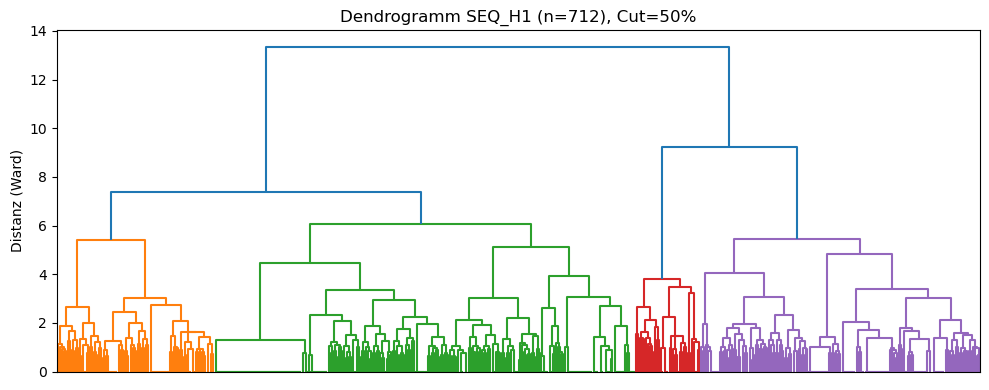


→ SEQ_H2: 712 Sequenzen zum Clustern
   MaxDist=10.447, Cut@50%=5.224
✅ TSV-Datei für SEQ_H2 geschrieben: data/cdr_cluster_ESMC_tsvs/clusters_SEQ_H2.tsv


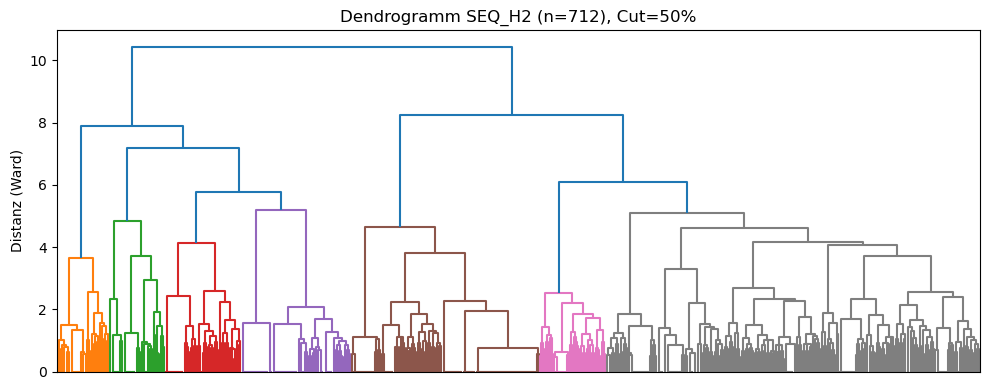


→ SEQ_L1: 712 Sequenzen zum Clustern
   MaxDist=20.233, Cut@50%=10.116
✅ TSV-Datei für SEQ_L1 geschrieben: data/cdr_cluster_ESMC_tsvs/clusters_SEQ_L1.tsv


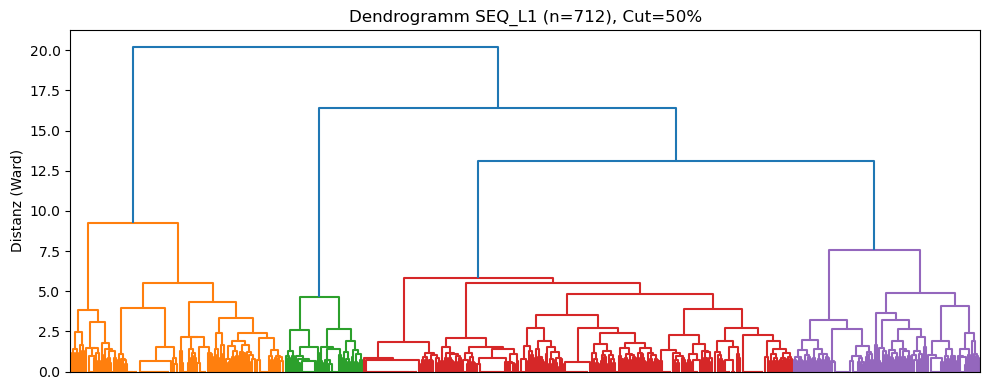


→ SEQ_L2: 712 Sequenzen zum Clustern
   MaxDist=12.782, Cut@50%=6.391
✅ TSV-Datei für SEQ_L2 geschrieben: data/cdr_cluster_ESMC_tsvs/clusters_SEQ_L2.tsv


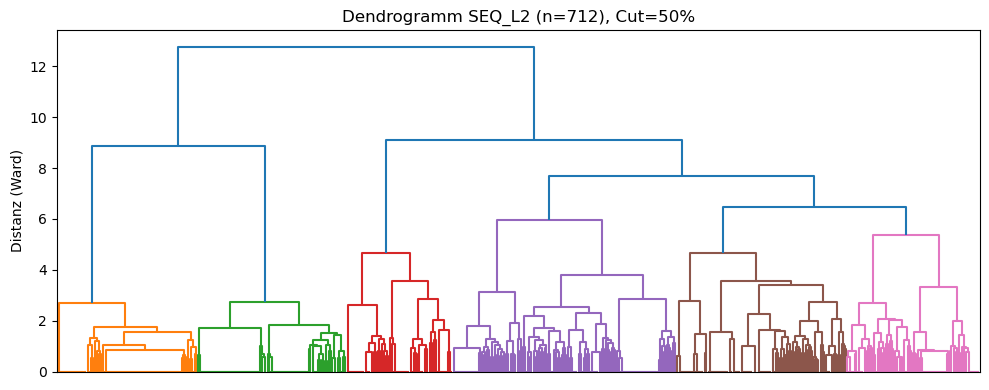


→ SEQ_L3: 712 Sequenzen zum Clustern
   MaxDist=22.485, Cut@50%=11.242
✅ TSV-Datei für SEQ_L3 geschrieben: data/cdr_cluster_ESMC_tsvs/clusters_SEQ_L3.tsv


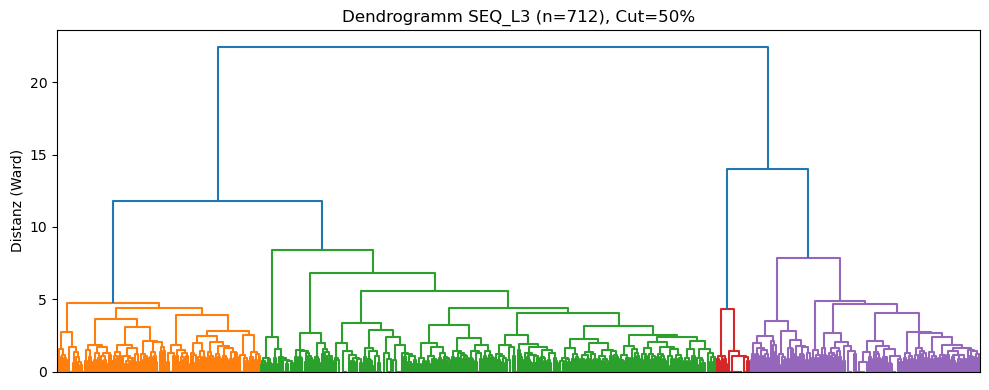

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import csv, os

# --------- Hierarchical Clustering aus bestehenden Feature-Spaces ohne vorsortierung ---------
# Jeder DataFrame enthält Spalten:
#   ['pdb', 'Hchain', 'Lchain', 'sequence',
#    'embedding_dimension 0', ..., 'embedding_dimension N']

threshold_ratio = 0.5  # 50% der maximalen Merge-Distanz als Cut
regions = ['SEQ_H1','SEQ_H2','SEQ_L1','SEQ_L2','SEQ_L3']

# Ausgabe-Ordner für TSVs
outdir = "data/cdr_cluster_ESMC_tsvs"
os.makedirs(outdir, exist_ok=True)

for region in regions:
    fs = feature_spaces.get(region)
    if fs is None or fs.empty:
        continue

    # 1) Embedding-Spalten sammeln
    emb_cols = [c for c in fs.columns if c.startswith('embedding_dimension')]
    if not emb_cols:
        continue

    # 2) Feature‐Matrix und Labels
    X = fs[emb_cols].values
    labels = (
        fs['pdb'].astype(str)
        + '_' + fs['Hchain'].fillna('')
        + fs['Lchain'].fillna('')
    )
    n = X.shape[0]
    print(f"\n→ {region}: {n} Sequenzen zum Clustern")
    if n < 2:
        continue

    # 3) Ward‐Linkage
    Z = linkage(X, method='ward', metric='euclidean')
    max_dist = Z[-1,2]
    cut = threshold_ratio * max_dist
    print(f"   MaxDist={max_dist:.3f}, Cut@{threshold_ratio*100:.0f}%={cut:.3f}")

    # 4) Cluster‐Labels ermitteln
    clusters = fcluster(Z, t=cut, criterion="distance")
    fs['cluster'] = clusters  # neue Spalte im DataFrame

    # 5) TSV schreiben – komplett alle Spalten + cluster
    out_path = os.path.join(outdir, f"clusters_{region}.tsv")
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        # Header: alle Spaltennamen
        writer.writerow(list(fs.columns))
        # Daten
        writer.writerows(fs.values)
    
    # 6) Dendrogramm plotten
    plt.figure(figsize=(10,4))
    dendrogram(
        Z,
        labels=labels.tolist(),
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=cut
    )
    plt.xticks([])
    plt.xlabel("")
    plt.ylabel("Distanz (Ward)")
    plt.title(f"Dendrogramm {region} (n={n}), Cut={int(threshold_ratio*100)}%")
    plt.tight_layout()
    plt.show()

      pdb Hchain Lchain  model                             antigen_name  \
0    8veb      G      I      0                            hemagglutinin   
1    8ved      H      L      0                            hemagglutinin   
2    8vef      H      L      0                            hemagglutinin   
3    8vpf      M      N      0                       spike glycoprotein   
4    9dpc      H      L      0                            neuraminidase   
..    ...    ...    ...    ...                                      ...   
707  5o4g      B      A      0  receptor tyrosine-protein kinase erbb-2   
708  7ntc      H      L      0                       spike glycoprotein   
709  6ofi      H      L      0       clade a/e 93th057 hiv-1 gp120 core   
710  7n62      H      L      0                       spike glycoprotein   
711  7n3d      H      L      0                            nucleoprotein   

                                     antigen_species     SEQ_H1  \
0                               

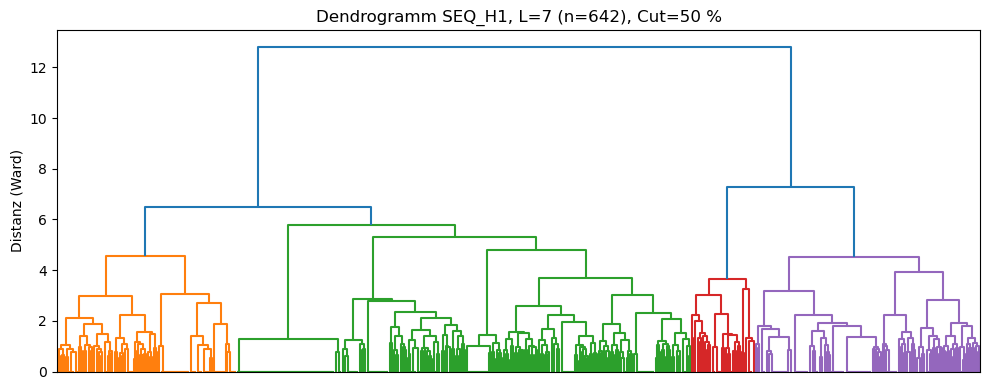


→ SEQ_H1, Länge=8: 11 Sequenzen
   MaxDist=3.903, Cut@50 % = 1.951


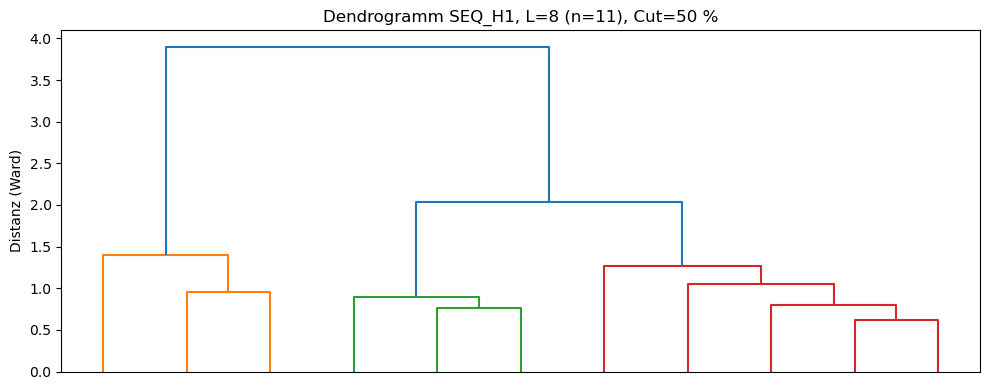


→ SEQ_H1, Länge=9: 59 Sequenzen
   MaxDist=5.489, Cut@50 % = 2.745


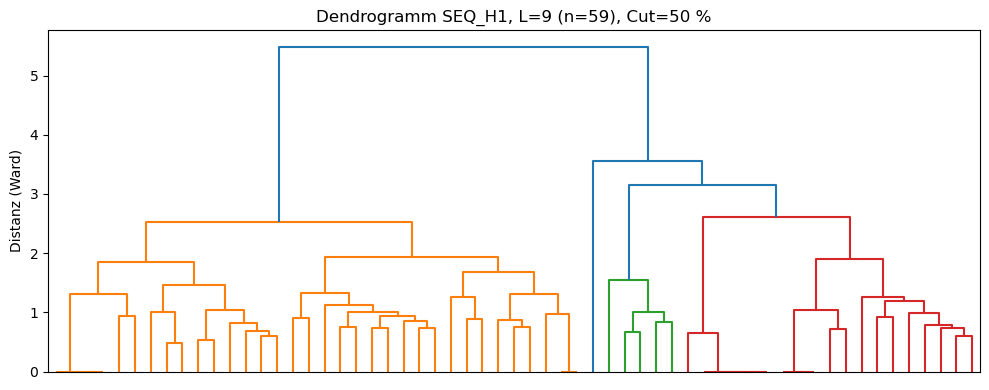

      pdb Hchain Lchain  model                             antigen_name  \
0    8veb      G      I      0                            hemagglutinin   
1    8ved      H      L      0                            hemagglutinin   
2    8vef      H      L      0                            hemagglutinin   
3    8vpf      M      N      0                       spike glycoprotein   
4    9dpc      H      L      0                            neuraminidase   
..    ...    ...    ...    ...                                      ...   
707  5o4g      B      A      0  receptor tyrosine-protein kinase erbb-2   
708  7ntc      H      L      0                       spike glycoprotein   
709  6ofi      H      L      0       clade a/e 93th057 hiv-1 gp120 core   
710  7n62      H      L      0                       spike glycoprotein   
711  7n3d      H      L      0                            nucleoprotein   

                                     antigen_species  SEQ_H2  \
0                                  

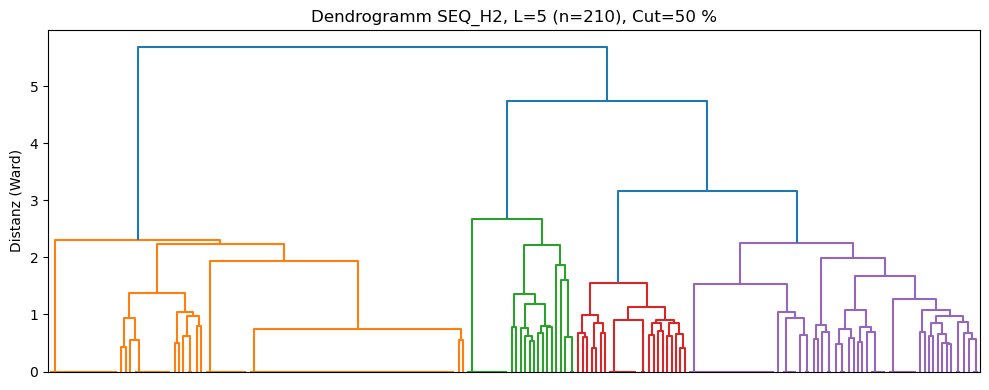


→ SEQ_H2, Länge=6: 488 Sequenzen
   MaxDist=10.288, Cut@50 % = 5.144


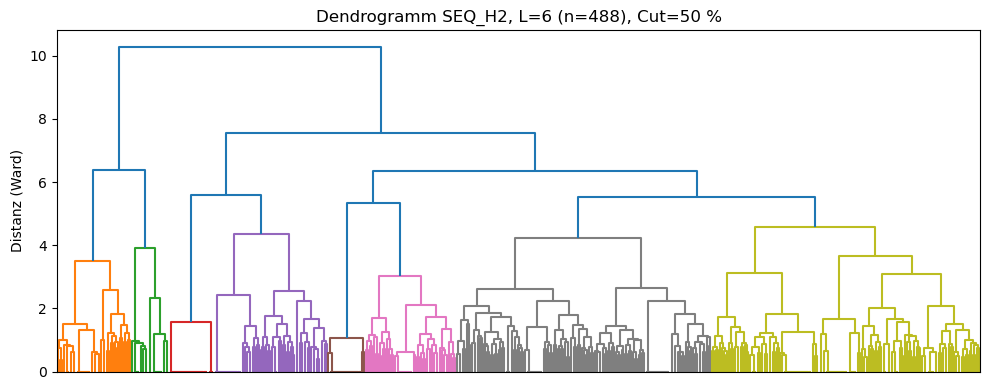


→ SEQ_H2, Länge=8: 14 Sequenzen
   MaxDist=1.890, Cut@50 % = 0.945


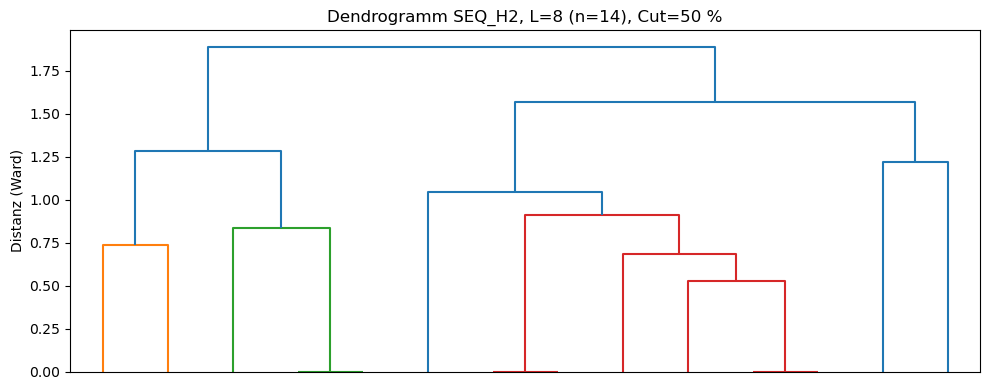

      pdb Hchain Lchain  model                             antigen_name  \
0    8veb      G      I      0                            hemagglutinin   
1    8ved      H      L      0                            hemagglutinin   
2    8vef      H      L      0                            hemagglutinin   
3    8vpf      M      N      0                       spike glycoprotein   
4    9dpc      H      L      0                            neuraminidase   
..    ...    ...    ...    ...                                      ...   
707  5o4g      B      A      0  receptor tyrosine-protein kinase erbb-2   
708  7ntc      H      L      0                       spike glycoprotein   
709  6ofi      H      L      0       clade a/e 93th057 hiv-1 gp120 core   
710  7n62      H      L      0                       spike glycoprotein   
711  7n3d      H      L      0                            nucleoprotein   

                                     antigen_species            SEQ_L1  \
0                        

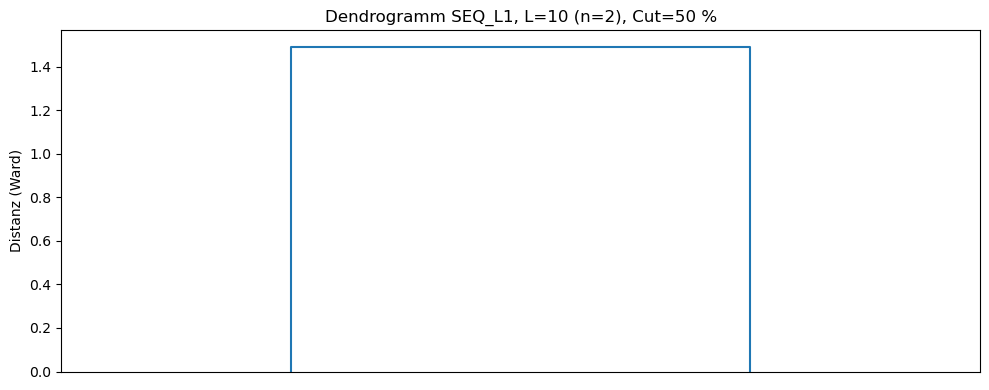


→ SEQ_L1, Länge=11: 387 Sequenzen
   MaxDist=11.942, Cut@50 % = 5.971


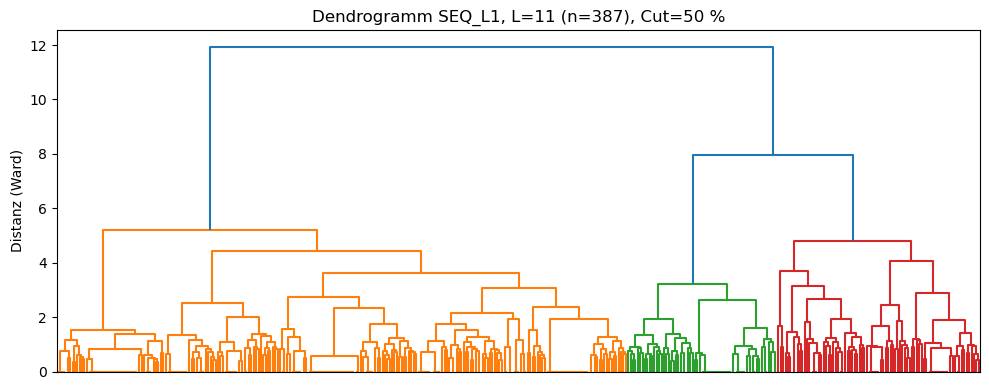


→ SEQ_L1, Länge=12: 98 Sequenzen
   MaxDist=3.830, Cut@50 % = 1.915


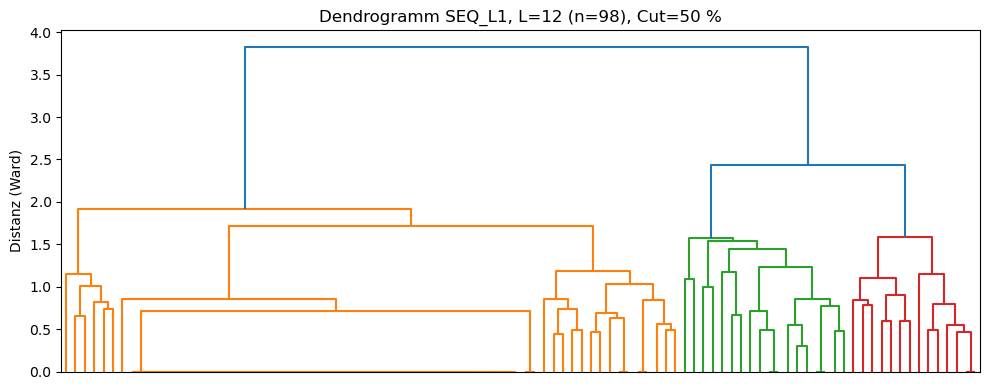


→ SEQ_L1, Länge=13: 59 Sequenzen
   MaxDist=6.262, Cut@50 % = 3.131


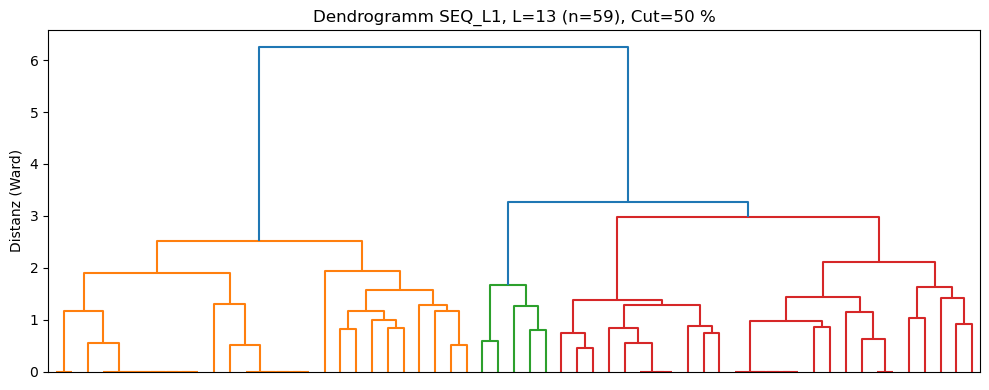


→ SEQ_L1, Länge=14: 101 Sequenzen
   MaxDist=4.842, Cut@50 % = 2.421


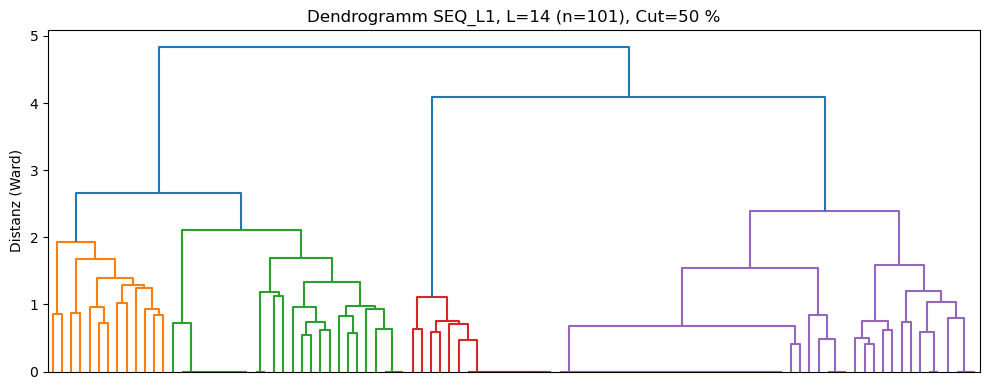


→ SEQ_L1, Länge=15: 5 Sequenzen
   MaxDist=1.433, Cut@50 % = 0.717


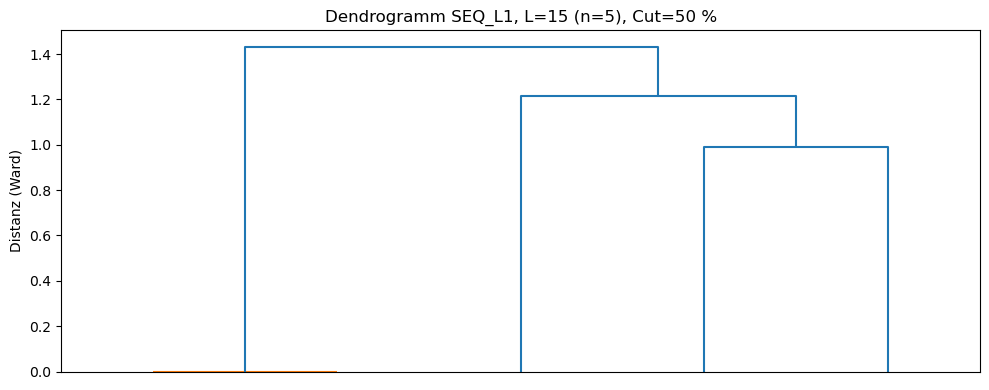


→ SEQ_L1, Länge=16: 35 Sequenzen
   MaxDist=2.614, Cut@50 % = 1.307


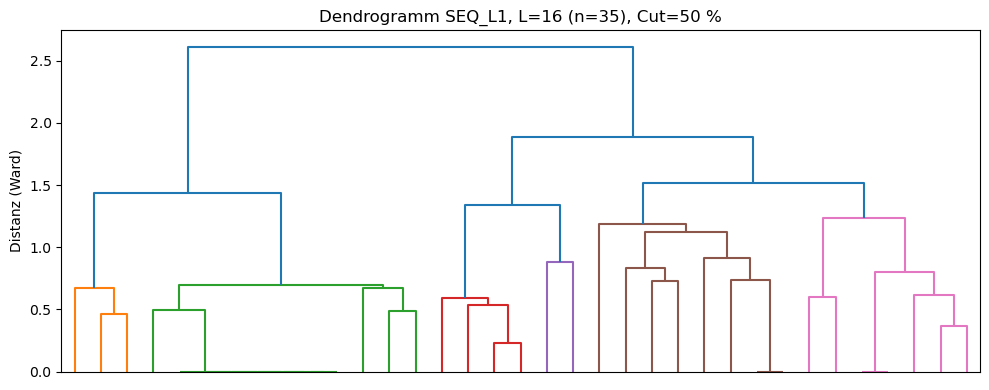


→ SEQ_L1, Länge=17: 25 Sequenzen
   MaxDist=2.314, Cut@50 % = 1.157


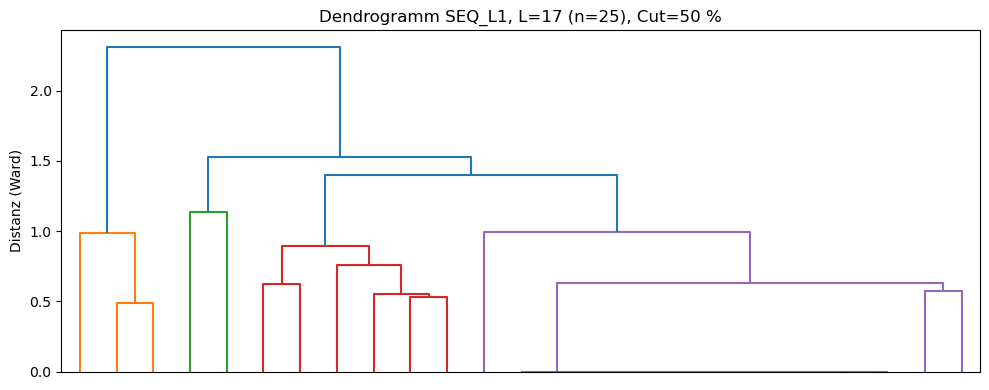

      pdb Hchain Lchain  model                             antigen_name  \
0    8veb      G      I      0                            hemagglutinin   
1    8ved      H      L      0                            hemagglutinin   
2    8vef      H      L      0                            hemagglutinin   
3    8vpf      M      N      0                       spike glycoprotein   
4    9dpc      H      L      0                            neuraminidase   
..    ...    ...    ...    ...                                      ...   
707  5o4g      B      A      0  receptor tyrosine-protein kinase erbb-2   
708  7ntc      H      L      0                       spike glycoprotein   
709  6ofi      H      L      0       clade a/e 93th057 hiv-1 gp120 core   
710  7n62      H      L      0                       spike glycoprotein   
711  7n3d      H      L      0                            nucleoprotein   

                                     antigen_species   SEQ_L2  \
0                                 

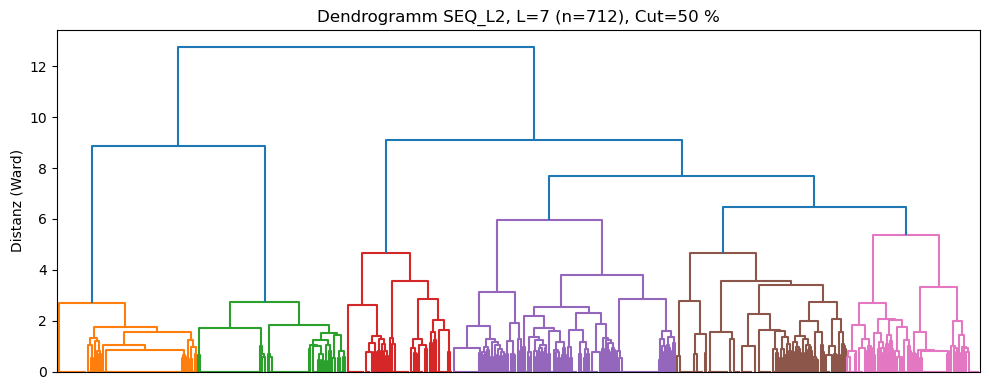

      pdb Hchain Lchain  model                             antigen_name  \
0    8veb      G      I      0                            hemagglutinin   
1    8ved      H      L      0                            hemagglutinin   
2    8vef      H      L      0                            hemagglutinin   
3    8vpf      M      N      0                       spike glycoprotein   
4    9dpc      H      L      0                            neuraminidase   
..    ...    ...    ...    ...                                      ...   
707  5o4g      B      A      0  receptor tyrosine-protein kinase erbb-2   
708  7ntc      H      L      0                       spike glycoprotein   
709  6ofi      H      L      0       clade a/e 93th057 hiv-1 gp120 core   
710  7n62      H      L      0                       spike glycoprotein   
711  7n3d      H      L      0                            nucleoprotein   

                                     antigen_species       SEQ_L3  \
0                             

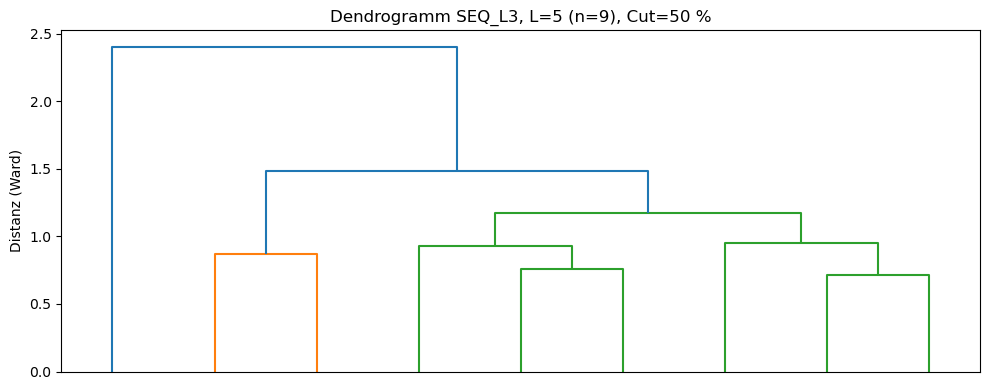


→ SEQ_L3, Länge=8: 47 Sequenzen
   MaxDist=4.389, Cut@50 % = 2.195


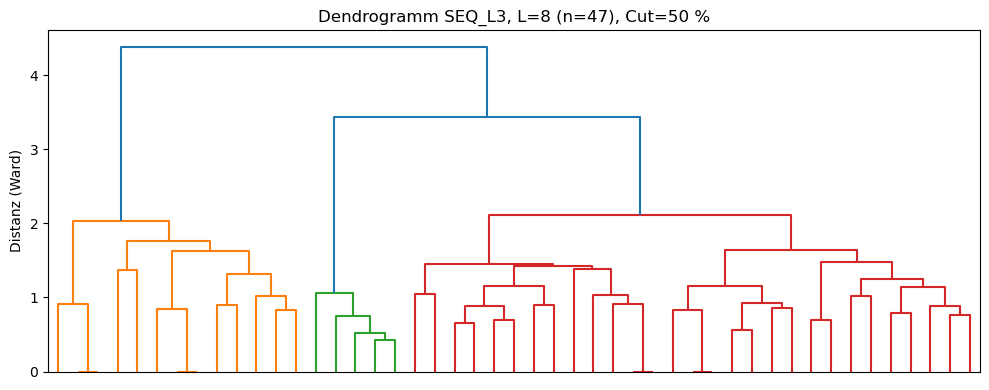


→ SEQ_L3, Länge=9: 390 Sequenzen
   MaxDist=21.161, Cut@50 % = 10.580


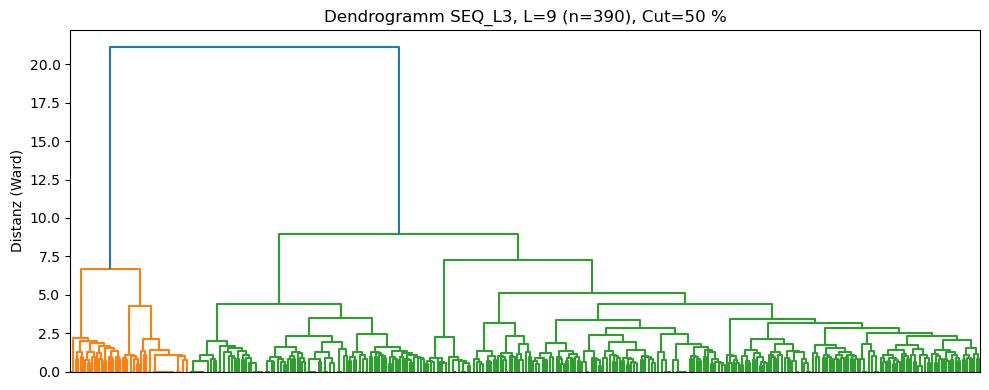


→ SEQ_L3, Länge=10: 161 Sequenzen
   MaxDist=8.704, Cut@50 % = 4.352


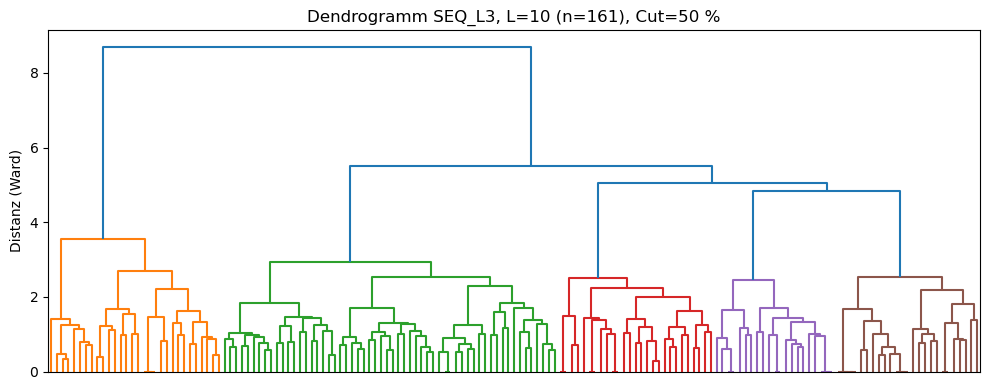


→ SEQ_L3, Länge=11: 105 Sequenzen
   MaxDist=5.478, Cut@50 % = 2.739


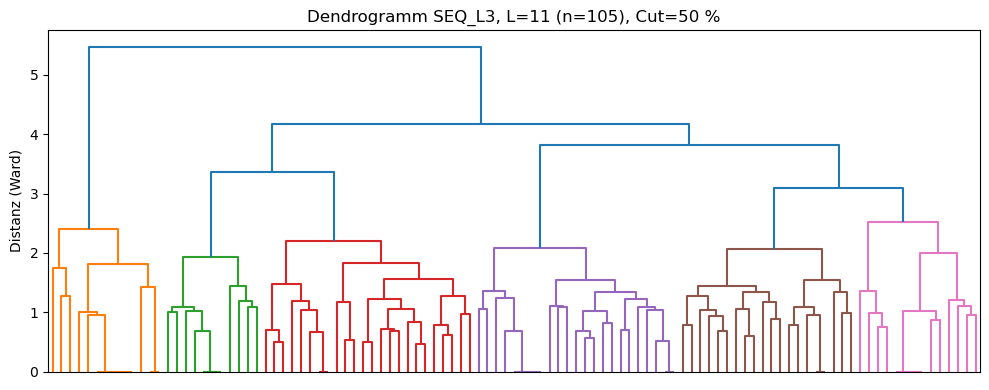

In [40]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 50 % der maximalen Merge-Distanz als Cut
threshold_ratio = 0.5

# CDR-Regionen (gleich den Keys in feature_spaces)


# Ausgabe-Ordner anlegen
outdir = "data/cdr_cluster_ESMC_tsvs_by_length"
os.makedirs(outdir, exist_ok=True)

for region in seq_regions:
    fs = feature_spaces.get(region)
    if fs is None or fs.empty:
        continue

    # Berechne Sequenz-Längen
    
    fs["length"] = [len(i) for i in fs[region]]
    print(fs)
    lengths = sorted(fs["length"].unique())

    for L in lengths:
        # Subset nur dieser Länge
        sub = fs[fs["length"] == L].reset_index(drop=True)
        n = len(sub)
        print(f"\n→ {region}, Länge={L}: {n} Sequenzen")

        if n < 2:
            print("   ► Zu wenige Einträge, überspringe.")
            continue

        # 1) Embedding-Spalten sammeln
        emb_cols = [c for c in sub.columns if c.startswith("emb_") or c.startswith("embedding_dimension")]
        if not emb_cols:
            print(f"   ⚠️ Keine Embedding-Spalten in {region}.")
            continue

        # 2) Feature-Matrix und Labels
        X = sub[emb_cols].values
        labels = ( sub["pdb"].astype(str)
                 + "_" + sub["Hchain"].fillna("")
                 + "_" + sub["Lchain"].fillna("") ).tolist()

        # 3) Ward-Linkage
        Z = linkage(X, method="ward", metric="euclidean")
        max_dist = Z[-1,2]
        cut = threshold_ratio * max_dist
        print(f"   MaxDist={max_dist:.3f}, Cut@{int(threshold_ratio*100)} % = {cut:.3f}")

        # 4) Cluster-Labels ermitteln
        sub["cluster"] = fcluster(Z, t=cut, criterion="distance")

        # 5) TSV schreiben (alle Spalten + cluster)
        out_path = os.path.join(outdir, f"clusters_{region}_len{L}.tsv")
        with open(out_path, "w", newline="") as f:
            writer = csv.writer(f, delimiter="\t")
            writer.writerow(list(sub.columns))           # Header
            writer.writerows(sub.values)                 # alle Zeilen
        

        # 6) Dendrogramm plotten
        plt.figure(figsize=(10,4))
        dendrogram(
            Z,
            labels=labels,
            leaf_rotation=90,
            leaf_font_size=6,
            color_threshold=cut
        )
        plt.xticks([]); plt.xlabel("")
        plt.ylabel("Distanz (Ward)")
        plt.title(f"Dendrogramm {region}, L={L} (n={n}), Cut={int(threshold_ratio*100)} %")
        plt.tight_layout()
        plt.show()

In [20]:
print(fs.columns)

Index(['pdb', 'Hchain', 'Lchain', 'model', 'antigen_name', 'antigen_species',
       'embedding_dimension 0', 'embedding_dimension 1',
       'embedding_dimension 2', 'embedding_dimension 3',
       ...
       'embedding_dimension 1143', 'embedding_dimension 1144',
       'embedding_dimension 1145', 'embedding_dimension 1146',
       'embedding_dimension 1147', 'embedding_dimension 1148',
       'embedding_dimension 1149', 'embedding_dimension 1150',
       'embedding_dimension 1151', 'cluster'],
      dtype='object', length=1159)


In [ ]:
data_cleanup.functions.show_PCA(feature_spaces, 3)

In [ ]:
data_cleanup.functions.elbow(feature_spaces, 3)

In [ ]:
data_cleanup.functions.silhouette(feature_spaces, 3)

In [ ]:
# Auswahl der optimalen Clusterzahlen für silhouette_check und show_Kmeans
cluster_counts = {
    "CDR_H1": 4,
    "CDR_H2": 6,
    "CDR_L1": 5,
    "CDR_L2": 7,
    "CDR_L3": 2
}

In [ ]:
data_cleanup.functions.silhouette_check(feature_spaces, cluster_counts, ncols=3)

In [ ]:
data_cleanup.functions.show_Kmeans(feature_spaces, cluster_counts, 3)

In [ ]:
#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären


In [ ]:
# Brauchen wir erst mal nicht!
'''# Alternative: Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling
from scipy.spatial.distance import directed_hausdorff
from sklearn.manifold import MDS

subset_df = df.sample(300, random_state=42)


for region in regions:
    alle_embeddings = []
    labels = []
    for i, df_row in subset_df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        #antigen_species = df_row["antigen_species"]
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        alle_embeddings.append(embedding_as_arr)
        labels.append(antigen_name)
    n = len(alle_embeddings)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(dist_matrix)

    label_codes = pd.Categorical(labels).codes
    label_categories = pd.Categorical(labels).categories
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=label_codes, cmap='tab10', s=20)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")
    plt.title(f"Embeddings der {region} (Hausdorff)")
    plt.grid(True)
    plt.show()'''